In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')


In [4]:
df = pd.read_csv("Telco-Customer-Churn.csv")

df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
df = df.drop(columns=["customerID"])

df["TotalCharges"] = df["TotalCharges"].replace({" " : "0.0"}).astype(float)

df.shape

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df["Churn"].value_counts()

print(f"Class Imbalance Ratio: {df['Churn'].value_counts()[0] / df['Churn'].value_counts()[1]:.2f}:1")

Class Imbalance Ratio: 2.77:1


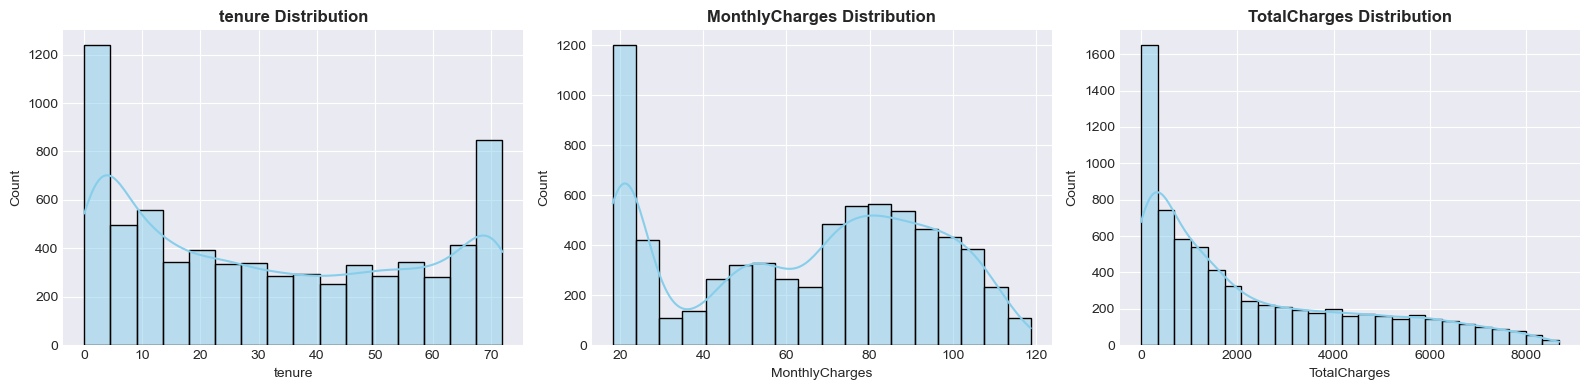

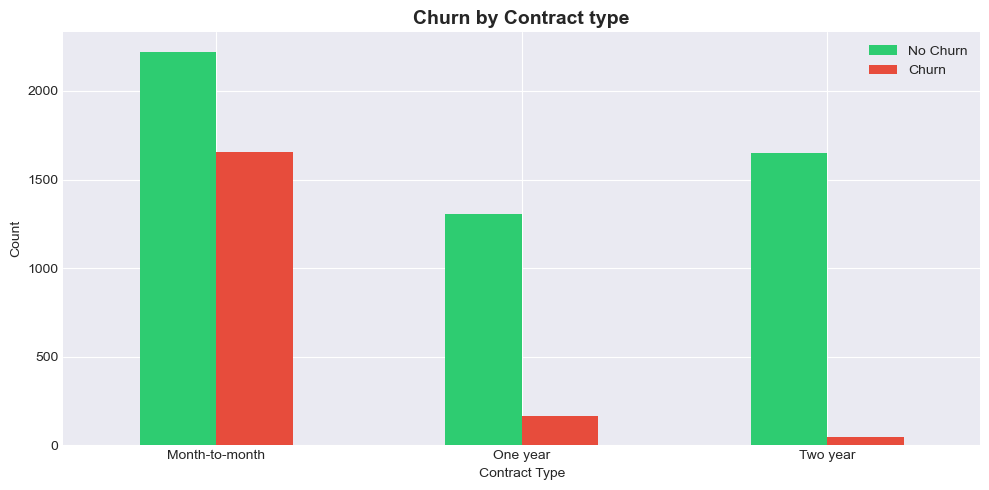

In [8]:
fig , axes = plt.subplots(1, 3, figsize=(16,4))

for idx, col in enumerate(["tenure", "MonthlyCharges","TotalCharges"]):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#churn by contract

fig, ax = plt.subplots(1,1, figsize=(10, 5))
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)
contract_churn.plot(kind='bar', stacked=False, ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Churn by Contract type', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Count')
ax.legend(['No Churn', 'Churn'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

In [9]:
#Encode binary columns

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

categorical_cols = ['MultipleLines','InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod']

encoders = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    encoders[col] = encoder

In [10]:
X = df.drop('Churn', axis=1)
Y = df['Churn']

x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, stratify=Y, random_state=42)

x_train.shape[0]

5634

In [11]:
x_test.shape[0]

1409

In [12]:
smote = SMOTE(random_state=42)

x_train_balanced, y_train_balanced = smote.fit_resample(x_train, y_train)


#before Smote
dict(y_train.value_counts())

{0: 4139, 1: 1495}

In [13]:
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)
ada_model = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.1, random_state=42)

ada_model.fit(x_train_balanced, y_train_balanced)


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   learning_rate=0.1, n_estimators=100, random_state=42)

In [14]:
y_train_pred = ada_model.predict(x_train)
y_test_pred = ada_model.predict(x_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)


In [15]:
print('Training Accuracy', train_acc)
print('Test Accuracy', test_acc)

Training Accuracy 0.7541711040113596
Test Accuracy 0.7409510290986515


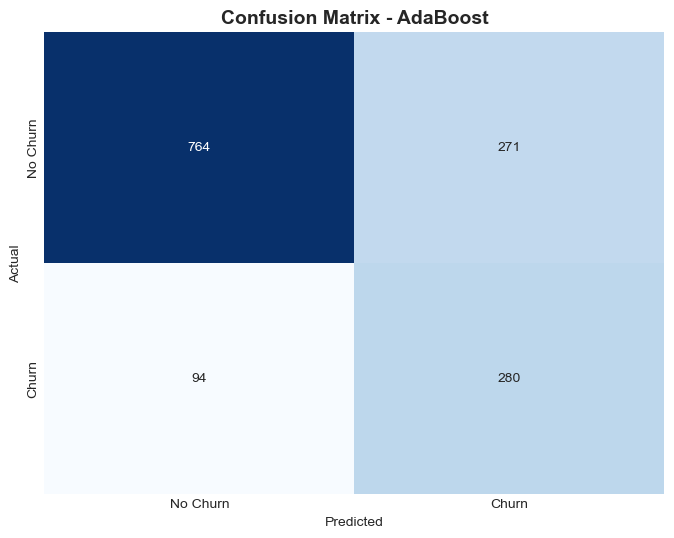

In [16]:
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])

plt.title('Confusion Matrix - AdaBoost', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


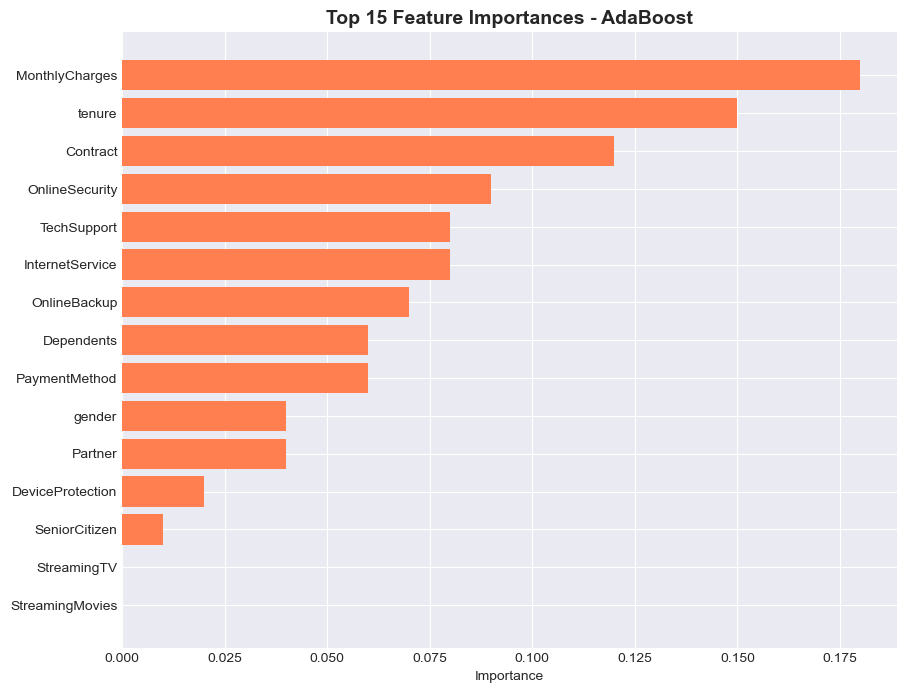

In [17]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': ada_model.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance.head(10)

plt.figure(figsize=(10,8))

plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15], color='coral')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - AdaBoost', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.show()


In [19]:
joblib.dump(ada_model, 'customer_churn_model.pkl')
joblib.dump(encoders, 'churn_encoders.pkl')


['churn_encoders.pkl']